# EDA проекта: Прогнозирование стоимости медицинского страхования

**Тема проекта:** анализ факторов, влияющих на индивидуальные расходы на медицинское страхование, и подготовка данных к моделированию.

**Датасет:** [Medical Cost Personal Datasets](https://www.kaggle.com/datasets/mirichoi0218/insurance) (Kaggle), файл `insurance.csv`, 1338 наблюдений, 7 признаков.

**Целевая переменная:** `charges` — индивидуальные медицинские расходы, выставленные страховой (USD).


## 1. Импорт библиотек

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (9, 5)

## 2. Загрузка данных

In [2]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Описание признаков

In [3]:
feature_description = pd.DataFrame({
    'feature':     ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'],
    'type':        ['int', 'cat', 'float', 'int', 'cat', 'cat', 'float (target)'],
    'description': [
        'возраст застрахованного, лет (18–64)',
        'пол: female / male',
        'индекс массы тела (кг/м²)',
        'число детей/иждивенцев в полисе (0–5)',
        'курит ли: yes / no',
        'регион проживания (northeast / northwest / southeast / southwest)',
        'индивидуальные медицинские расходы, USD',
    ],
})
feature_description

,feature,type,description
0,age,int,"возраст застрахованного, лет (18–64)"
1,sex,cat,пол: female / male
2,bmi,float,индекс массы тела (кг/м²)
3,children,int,число детей/иждивенцев в полисе (0–5)
4,smoker,cat,курит ли: yes / no
5,region,cat,регион проживания (northeast / northwest / sou...
6,charges,float (target),"индивидуальные медицинские расходы, USD"


## 4. Общий обзор структуры данных

In [4]:
print('Размер датасета:', df.shape)

Размер датасета: (1338, 7)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
summary_table = pd.DataFrame({
    'dtype':    df.dtypes.astype(str),
    'n_unique': df.nunique(),
    'n_missing': df.isna().sum(),
    'example':  df.iloc[0].astype(str).values,
})
summary_table

,dtype,n_unique,n_missing,example
age,int64,47,0,19
sex,object,2,0,female
bmi,float64,548,0,27.9
children,int64,6,0,0
smoker,object,2,0,yes
region,object,4,0,southwest
charges,float64,1337,0,16884.924


In [7]:
print('Полных дубликатов:', df.duplicated().sum())

Полных дубликатов: 1


In [8]:
df = df.drop_duplicates().reset_index(drop=True)
print('Размер после удаления дубликатов:', df.shape)

Размер после удаления дубликатов: (1337, 7)


### Вывод по качеству данных
Пропусков нет, типы корректные, удалён единственный дубликат. Дополнительная очистка не требуется.


## 5. Описательная статистика

In [9]:
df.describe().round(2)

,age,bmi,children,charges
count,1337.00,1337.00,1337.00,1337.00
mean,39.22,30.66,1.10,13279.12
std,14.04,6.10,1.21,12110.36
min,18.00,15.96,0.00,1121.87
25%,27.00,26.29,0.00,4746.34
50%,39.00,30.40,1.00,9386.16
75%,51.00,34.70,2.00,16657.72
max,64.00,53.13,5.00,63770.43


In [10]:
df.describe(include='object')

,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


## 6. Распределение целевой переменной `charges`

`charges` — непрерывная неотрицательная величина. Посмотрим её распределение и проверим, нужно ли логарифмировать.


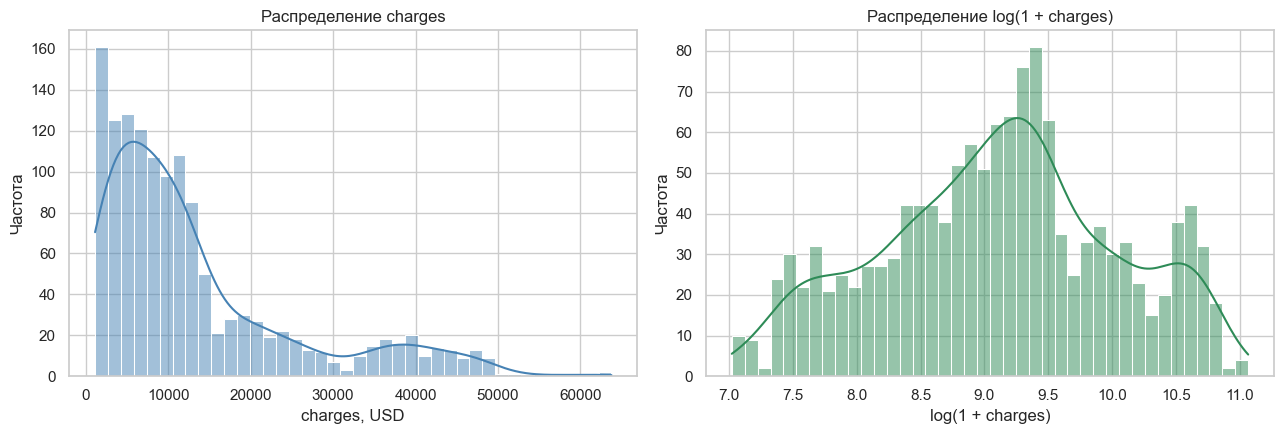

skew исходный: 1.515
skew log     : -0.090


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['charges'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Распределение charges')
axes[0].set_xlabel('charges, USD'); axes[0].set_ylabel('Частота')

sns.histplot(np.log1p(df['charges']), bins=40, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Распределение log(1 + charges)')
axes[1].set_xlabel('log(1 + charges)'); axes[1].set_ylabel('Частота')
plt.tight_layout(); plt.show()

print(f"skew исходный: {df['charges'].skew():.3f}")
print(f"skew log     : {np.log1p(df['charges']).skew():.3f}")

### Вывод
`charges` сильно скошен вправо (skew ≈ 1.5); логарифм делает распределение почти симметричным (skew ≈ −0.1).


## 7. Анализ числовых признаков (`age`, `bmi`, `children`)

Гистограмма + boxplot — позволяют сразу увидеть форму распределения и выбросы.


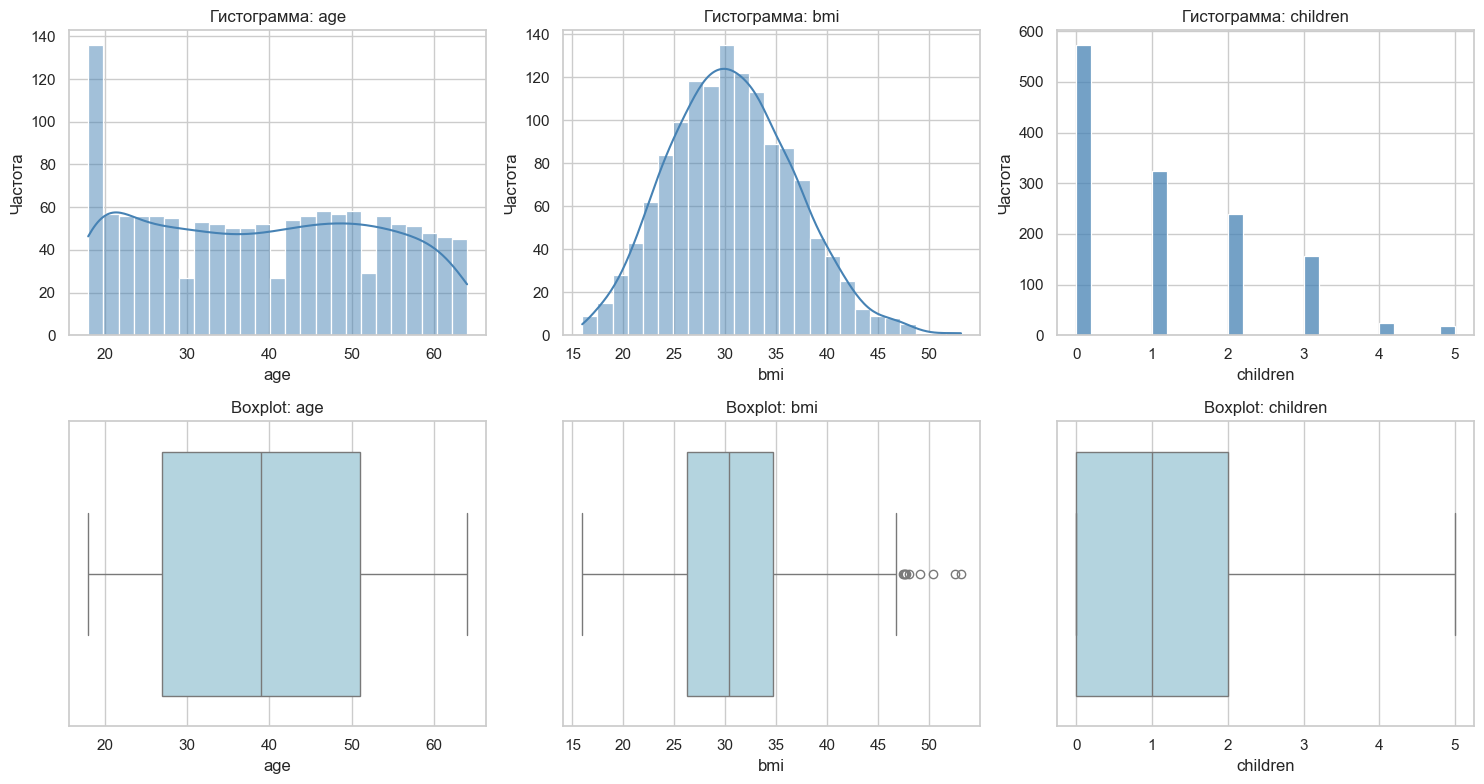

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_cols = ['age', 'bmi', 'children']
for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=25, kde=(col != 'children'), ax=axes[0, i], color='steelblue')
    axes[0, i].set_title(f'Гистограмма: {col}')
    axes[0, i].set_xlabel(col); axes[0, i].set_ylabel('Частота')
    sns.boxplot(x=df[col], ax=axes[1, i], color='lightblue')
    axes[1, i].set_title(f'Boxplot: {col}'); axes[1, i].set_xlabel(col)
plt.tight_layout(); plt.show()

## 8. Анализ категориальных признаков (`sex`, `smoker`, `region`)


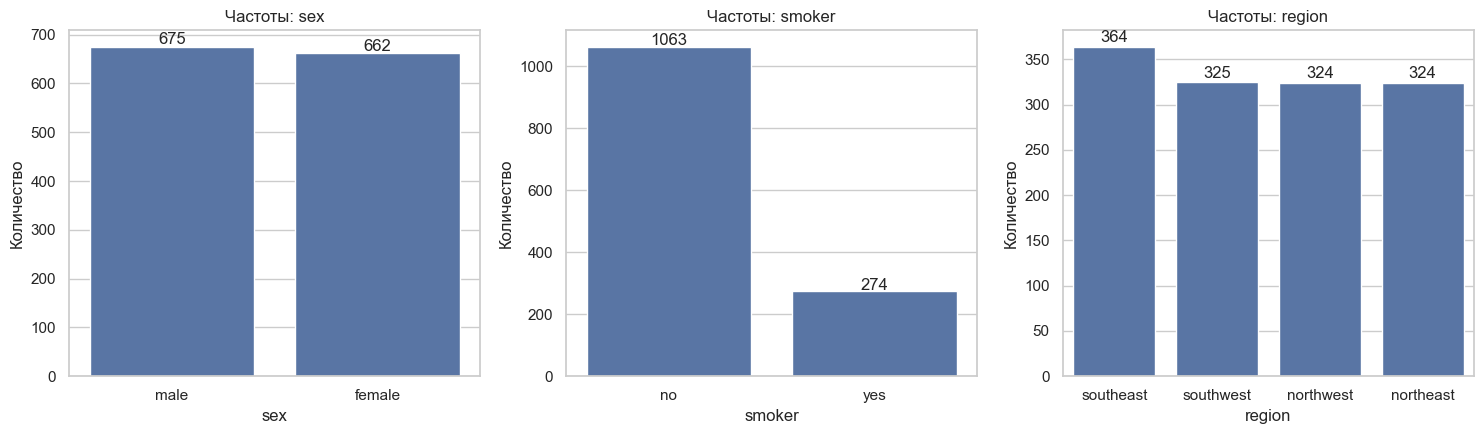

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for i, col in enumerate(['sex', 'smoker', 'region']):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i])
    axes[i].set_title(f'Частоты: {col}')
    axes[i].set_xlabel(col); axes[i].set_ylabel('Количество')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha='center')
plt.tight_layout(); plt.show()

### Вывод
`sex` и `region` сбалансированы; `smoker` сильно несбалансирован (≈ 20% курящих) — учтём при анализе влияния на `charges`.


## 9. Корреляционный анализ числовых признаков




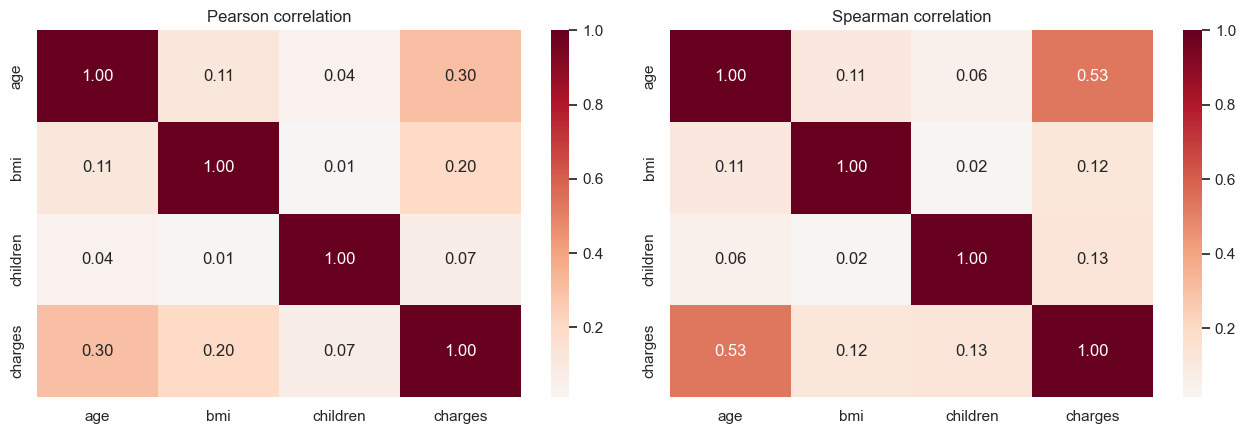

In [14]:
num_full = ['age', 'bmi', 'children', 'charges']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(df[num_full].corr(method='pearson'), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=axes[0])
axes[0].set_title('Pearson correlation')
sns.heatmap(df[num_full].corr(method='spearman'), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=axes[1])
axes[1].set_title('Spearman correlation')
plt.tight_layout(); plt.show()

## 10. Двухмерный анализ: ключевые срезы




### 10.1. Курение vs charges

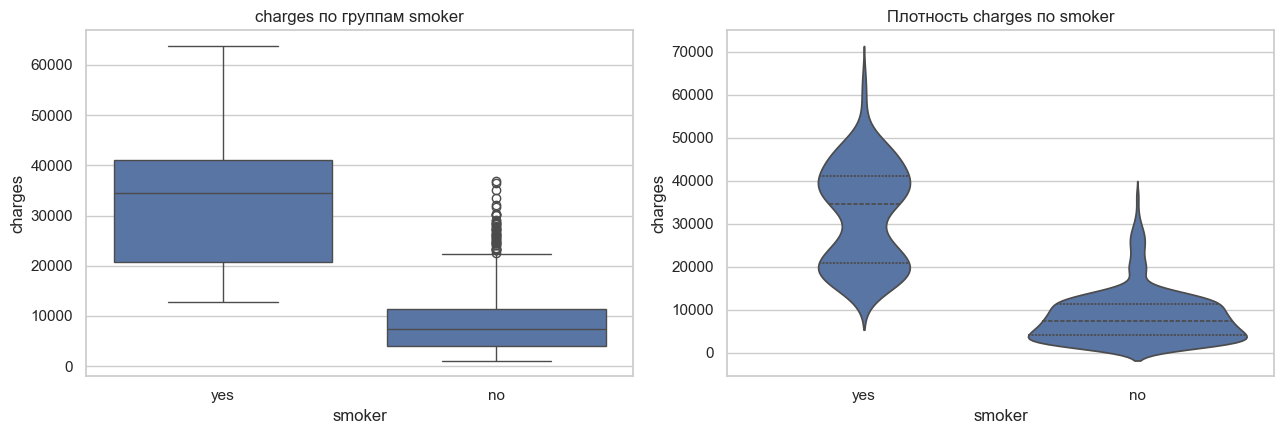

        count      mean    median
smoker                           
no       1063   8440.66   7345.73
yes       274  32050.23  34456.35


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df, x='smoker', y='charges', ax=axes[0])
axes[0].set_title('charges по группам smoker')
sns.violinplot(data=df, x='smoker', y='charges', ax=axes[1], inner='quartile')
axes[1].set_title('Плотность charges по smoker')
plt.tight_layout(); plt.show()
print(df.groupby('smoker')['charges'].agg(['count', 'mean', 'median']).round(2))

### 10.2. Возраст vs charges

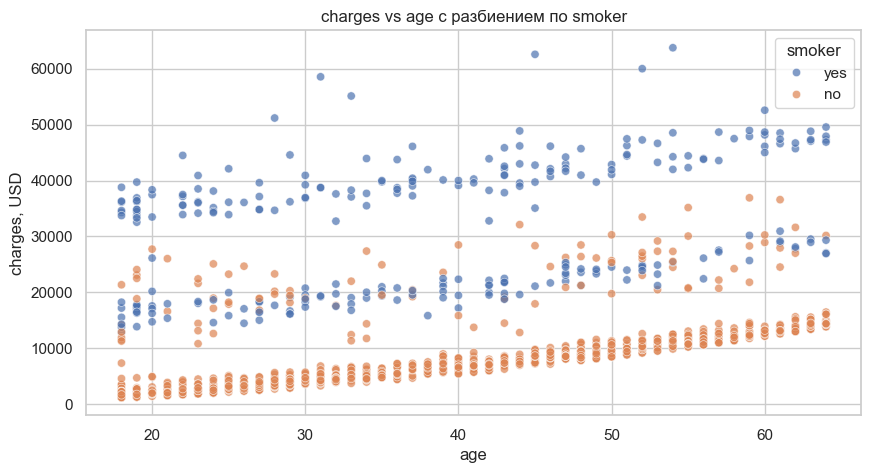

In [16]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.7)
plt.title('charges vs age с разбиением по smoker')
plt.xlabel('age'); plt.ylabel('charges, USD')
plt.legend(title='smoker'); plt.show()

### 10.3. BMI vs charges

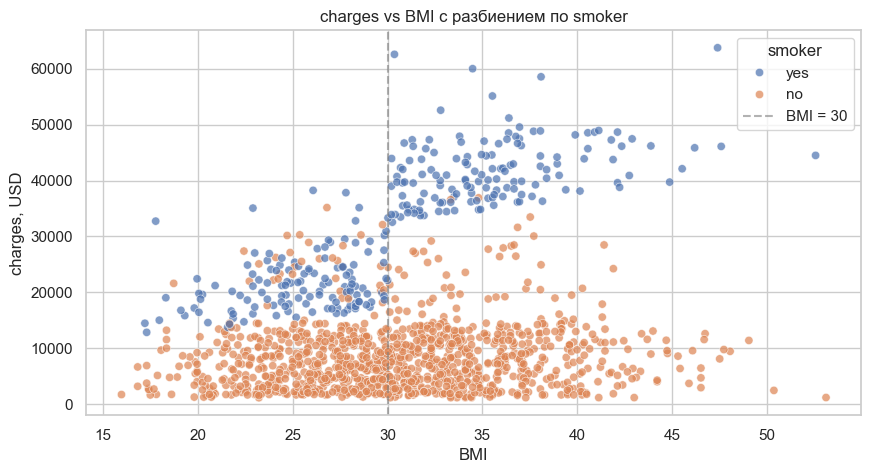

In [17]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.7)
plt.axvline(30, color='gray', linestyle='--', alpha=0.6, label='BMI = 30')
plt.title('charges vs BMI с разбиением по smoker')
plt.xlabel('BMI'); plt.ylabel('charges, USD')
plt.legend(title='smoker'); plt.show()

### 10.4. children, sex, region vs charges

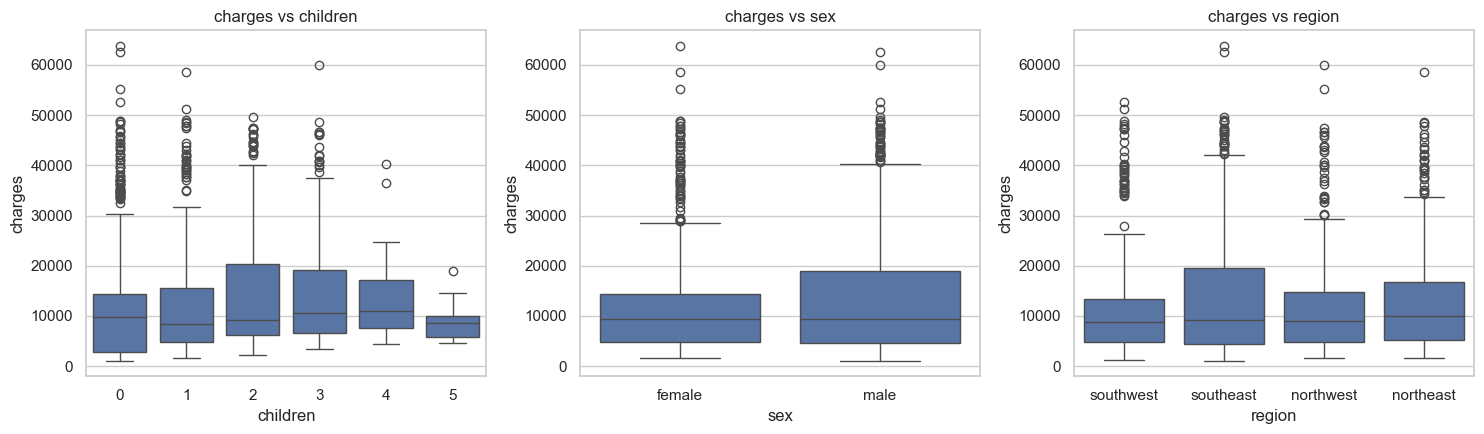

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(data=df, x='children', y='charges', ax=axes[0]); axes[0].set_title('charges vs children')
sns.boxplot(data=df, x='sex', y='charges', ax=axes[1]);      axes[1].set_title('charges vs sex')
sns.boxplot(data=df, x='region', y='charges', ax=axes[2]);   axes[2].set_title('charges vs region')
plt.tight_layout(); plt.show()

### Вывод
Главный драйвер — `smoker`. Хорошо виден сильный эффект взаимодействия `smoker × bmi` (резкий рост charges у курящих с ожирением). `sex`, `children` и `region` практически не влияют.


## 11. Статистические тесты для групповых различий



In [19]:
smokers = df.loc[df['smoker'] == 'yes', 'charges']
non_smokers = df.loc[df['smoker'] == 'no', 'charges']
t_stat, t_p = stats.ttest_ind(smokers, non_smokers, equal_var=False)
u_stat, u_p = stats.mannwhitneyu(smokers, non_smokers, alternative='two-sided')
print(f"Welch t-test smoker vs non-smoker:  t = {t_stat:.2f}, p = {t_p:.2e}")
print(f"Mann-Whitney smoker vs non-smoker: U = {u_stat:.0f}, p = {u_p:.2e}")

Welch t-test smoker vs non-smoker:  t = 32.74, p = 6.26e-103
Mann-Whitney smoker vs non-smoker: U = 283859, p = 5.75e-130


In [20]:
groups = [df.loc[df['region'] == r, 'charges'].values for r in df['region'].unique()]
f_stat, f_p = stats.f_oneway(*groups)
kw_stat, kw_p = stats.kruskal(*groups)
print(f"ANOVA по region:  F = {f_stat:.2f}, p = {f_p:.4f}")
print(f"Kruskal по region: H = {kw_stat:.2f}, p = {kw_p:.4f}")

ANOVA по region:  F = 2.93, p = 0.0328
Kruskal по region: H = 4.62, p = 0.2016


In [21]:
m = df.loc[df['sex'] == 'male', 'charges']
f = df.loc[df['sex'] == 'female', 'charges']
t_sex, p_sex = stats.ttest_ind(m, f, equal_var=False)
u_sex, p_u_sex = stats.mannwhitneyu(m, f, alternative='two-sided')
print(f"Welch t-test male vs female: t = {t_sex:.2f}, p = {p_sex:.4f}")
print(f"Mann-Whitney male vs female: U = {u_sex:.0f}, p = {p_u_sex:.4f}")

Welch t-test male vs female: t = 2.13, p = 0.0336
Mann-Whitney male vs female: U = 226198, p = 0.6945


### Интерпретация
Курение значимо при любом разумном уровне (p ≈ 10⁻¹³⁰); региональные и половые различия слабые (значимы только параметрические тесты по средним, но не по рангам).


## 12. Поиск выбросов

Используем правило 1.5·IQR.


In [22]:
def iqr_bounds(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

for col in ['age', 'bmi', 'charges']:
    lo, hi = iqr_bounds(df[col])
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'{col:8s}  bounds=[{lo:.1f}, {hi:.1f}]  outliers={n_out}')

age       bounds=[-9.0, 87.0]  outliers=0
bmi       bounds=[13.7, 47.3]  outliers=9
charges   bounds=[-13120.7, 34524.8]  outliers=139


### Вывод
Выбросы в `charges` — реальные дорогие пациенты (курящие с ожирением), не ошибки ввода. Удалять не будем.


## 13. Итоговые выводы EDA

1. Пропусков нет, 1337 строк после удаления одного дубликата.
2. `charges` сильно скошен вправо; log-преобразование делает распределение почти симметричным.
3. `smoker` — самый сильный одиночный предиктор (p ≈ 10⁻¹³⁰).
4. Сильное взаимодействие `smoker × bmi` — основа для конструирования признаков в Project.


## 14. Формулировка задачи, моделей и метрик

**Регрессия:** прогноз `charges`.
Модели: Linear Regression, Ridge, Random Forest.
Метрики: MAE, RMSE, R², CV-R² (5-fold).
